In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [16]:
df = pd.read_csv('data_science_job.csv')

In [17]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [18]:
df.isnull().mean()*100 # missing value percentage 

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [19]:
df.shape

(19158, 13)

In [20]:
cols = [var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols
# Since True is treated as 1 and False as 0, taking the mean gives the percentage/proportion of missing values.

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

### List comprehension
### cols = [var for var in df.columns if condition]

In [21]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14278,0.939,no_enrollment,Graduate,15.0,46.0
5660,0.920,no_enrollment,Graduate,20.0,17.0
7049,0.913,no_enrollment,Masters,20.0,50.0
1808,0.624,no_enrollment,Graduate,10.0,34.0
15759,0.897,no_enrollment,Masters,16.0,102.0


In [22]:
len(df[cols].dropna())/len(df[cols])*100 # it tells after deleting the rows how much percent data left 

89.68577095730244

In [23]:
new_df = df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

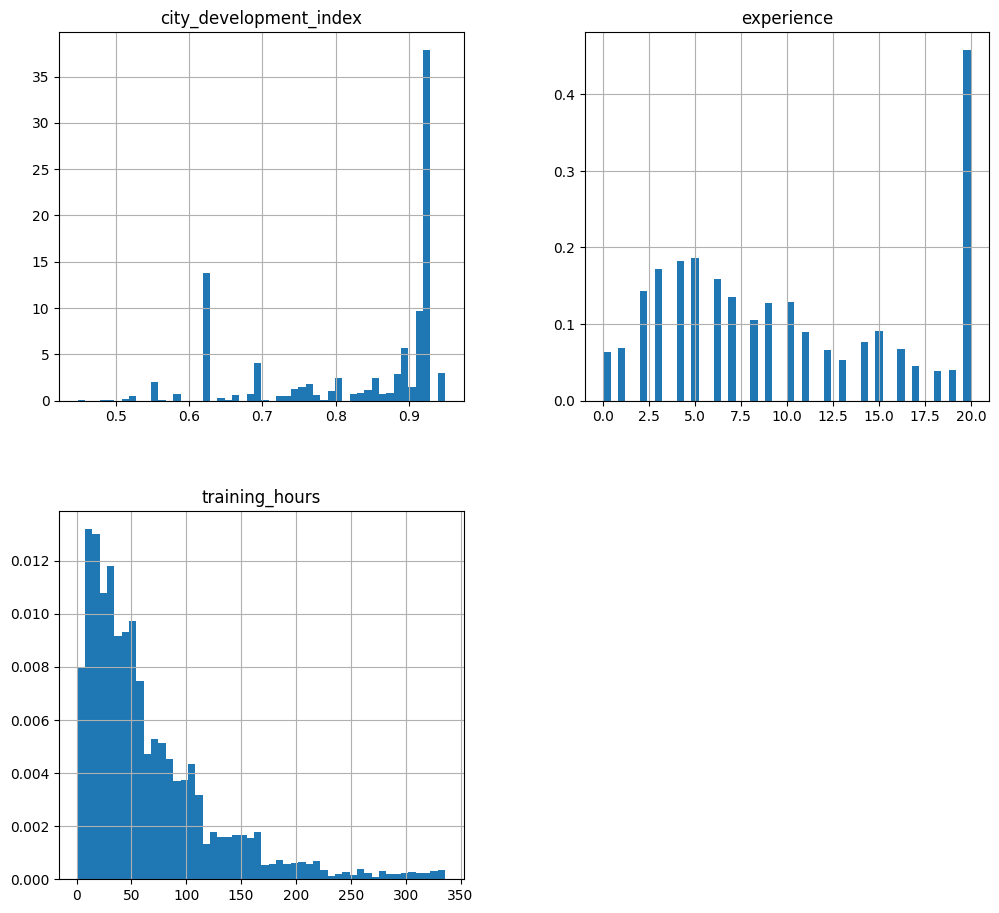

In [24]:
new_df.hist(bins=50,density=True,figsize=(12,11))
plt.show()

<Axes: >

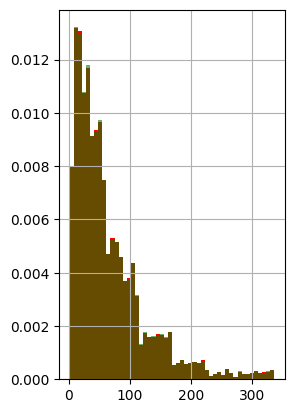

In [ ]:
# Now, plot histograms of the original DataFrame and the new DataFrame after applying CCA. If the distributions of the variables in both DataFrames are similar, then applying CCA is considered appropriate.
figure = plt.figure()
ax = figure.add_subplot(121)

# original data 
df['training_hours'].hist(bins=50,ax=ax,density=True,color='Red')

# data after cca , the argument alpha makes the color transparent, so we can see the overlap of 2 distribution 
new_df['training_hours'].hist(bins=50,density=True,color='Green',alpha=0.6)

# by seeing the below graph we can say the distribution is same so it is good to apply cca 

<Axes: ylabel='Density'>

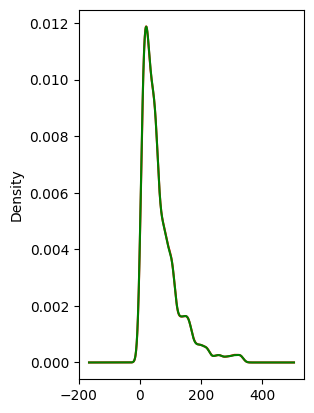

In [ ]:
# pdf - > probability density function 
fig = plt.figure()
ax = fig.add_subplot(121)

# original data 
df['training_hours'].plot.density(color='Red')

# new_data

new_df['training_hours'].plot.density(color='Green')

# since the green overlaps the red graph -> this proves that the distribution of data does not change after removing the missing values and it also proves that the data was missing randomly -> overall good for applying CCA

<Axes: >

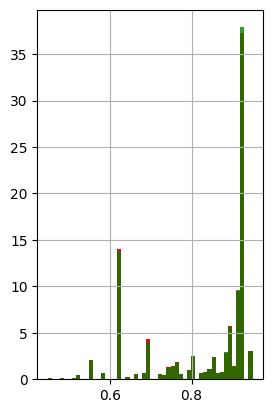

In [37]:
fig = plt.figure()
ax = fig.add_subplot(121)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

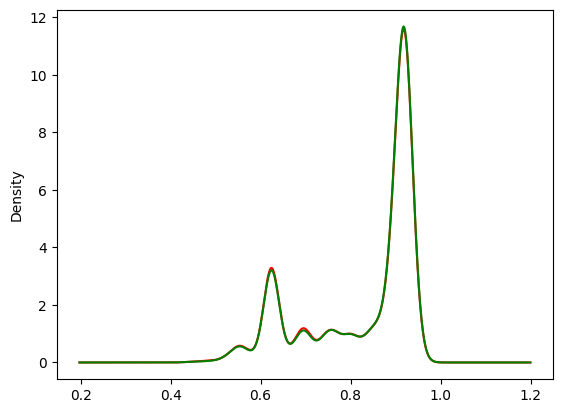

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: >

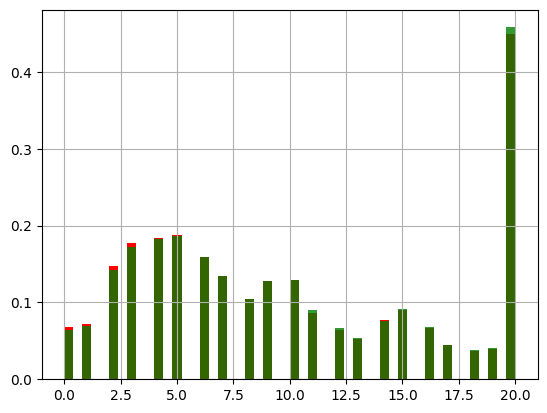

In [39]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

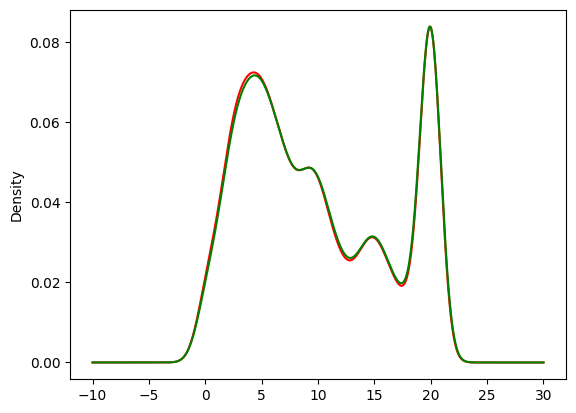

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

In [41]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
669,16372,city_114,0.926,NaN,Has relevent experience,Full time course,Masters,STEM,9.0,50-99,Pvt Ltd,88.0,0.0
7667,18088,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,Arts,1.0,<10,Early Stage Startup,5.0,0.0
859,365,city_103,0.920,Female,Has relevent experience,no_enrollment,Masters,STEM,10.0,50-99,Pvt Ltd,16.0,0.0
2895,27871,city_75,0.939,NaN,Has relevent experience,no_enrollment,Graduate,STEM,7.0,50-99,Pvt Ltd,108.0,0.0
9833,17143,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,20.0,100-500,Pvt Ltd,130.0,0.0


In [44]:
# Now to apply cca in cate gorical columns the ratio of each category should remain same before and after applying the CCA -> this proves that the data was missing randomly 
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [45]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [ ]:
len(df) # it given number of rows 

19158

In [ ]:
temp = pd.concat([
    # percentage of observations per category ,original data 
    df['enrolled_university'].value_counts()/len(df),

    # percentage of observations per category , CCA data 
    new_df['enrolled_university'].value_counts()/len(new_df)
],
axis=1)

temp.columns = ['Original','CCA']
temp

# the difference in percentage in below table is acceptable 

,Original,CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [52]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
